# 02 - Ingeniería de Features

## Etapa 2 del Ciclo de Vida MLOps: Transformación del Dato

La ingeniería de features es el arte y la ciencia de transformar datos crudos en representaciones que los algoritmos de ML puedan aprovechar mejor. En MLOps, este proceso debe ser:

- **Reproducible**: el mismo código genera las mismas features siempre
- **Trazable**: cada transformación está documentada y versionada
- **Libre de data leakage**: las estadísticas se calculan solo con datos de entrenamiento

**¿Qué haremos en este notebook?**
1. Crear features derivadas que capturen relaciones conocidas del dominio
2. Demostrar el concepto de Data Leakage y cómo evitarlo
3. Aplicar estandarización correctamente
4. Documentar cada feature para el equipo de ML

## Prerequisitos
- Haber ejecutado: `01_eda_exploratorio.ipynb`
- Requiere: `data/raw/housing_raw.csv`
- Este notebook genera: `data/processed/train.csv` y `data/processed/test.csv`

## 1. Imports y Carga de Datos

Cargamos los datos crudos para partir desde el mismo punto de inicio que el EDA.

In [1]:
from pathlib import Path
import sys

# Detectar ROOT automáticamente — funciona en cualquier equipo
ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
# Añadir ROOT al path para importar módulos del proyecto
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

# Cargar datos
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print(f"Dataset cargado: {df.shape}")
print(f"Features originales: {[c for c in df.columns if c != 'MedHouseVal']}")
print(f"Variable objetivo: MedHouseVal")
df.head()

Dataset cargado: (20640, 9)
Features originales: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Variable objetivo: MedHouseVal


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
import pandas as pd

# Verificar prerequisito
ruta_raw = ROOT / "data" / "raw" / "housing_raw.csv"
if not ruta_raw.exists():
    print("PREREQUISITO FALTANTE: housing_raw.csv no encontrado.")
    print("   Ejecuta primero: 01_eda_exploratorio.ipynb")
    raise FileNotFoundError(f"No se encuentra: {ruta_raw}")

_df_check = pd.read_csv(ruta_raw)
print(f"Datos disponibles en: {ruta_raw}")
print(f"   Shape: {_df_check.shape}")
print(f"   Columnas: {list(_df_check.columns)}")
del _df_check  # No sobreescribimos 'df' — el notebook carga sus propios datos más abajo

Datos disponibles en: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\data\raw\housing_raw.csv
   Shape: (20640, 9)
   Columnas: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


## 2. Features Originales — Estadísticas Base

Establecemos una línea base con las features originales para comparar después de la ingeniería.

In [3]:
features_originales = [c for c in df.columns if c != 'MedHouseVal']

print("=== Estadísticas de Features Originales ===")
stats = df[features_originales].describe().round(3)
print(stats)

print("\n=== Correlación con MedHouseVal (baseline) ===")
corr_original = df[features_originales].corrwith(df['MedHouseVal']).sort_values(key=abs, ascending=False)
for feat, val in corr_original.items():
    print(f"  {feat:15s}: {val:+.3f}")

=== Estadísticas de Features Originales ===


          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.097    1425.477      3.071   
std        1.900     12.586      2.474      0.474    1132.462     10.386   
min        0.500      1.000      0.846      0.333       3.000      0.692   
25%        2.563     18.000      4.441      1.006     787.000      2.430   
50%        3.535     29.000      5.229      1.049    1166.000      2.818   
75%        4.743     37.000      6.052      1.100    1725.000      3.282   
max       15.000     52.000    141.909     34.067   35682.000   1243.333   

        Latitude  Longitude  
count  20640.000  20640.000  
mean      35.632   -119.570  
std        2.136      2.004  
min       32.540   -124.350  
25%       33.930   -121.800  
50%       34.260   -118.490  
75%       37.710   -118.010  
max       41.950   -114.310  

=== Correlación con MedHouseVal (baseline) =

## 3. Creación de Features Derivadas

Creamos nuevas variables a partir de las existentes basándonos en conocimiento del dominio:

| Feature Derivada | Fórmula | Justificación |
|-----------------|---------|---------------|
| `rooms_per_person` | AveRooms / AveOccup | Espacio real disponible por persona — captura densidad habitacional |
| `income_per_room` | MedInc / AveRooms | Poder adquisitivo relativo al tamaño — proxy de lujo |
| `bedroom_ratio` | AveBedrms / AveRooms | Proporción de dormitorios — diferencia casas de apartamentos |
| `dist_sacramento` | distancia eucl. a Sacramento | Sacramento es la capital y hub económico del norte de CA |
| `dist_los_angeles` | distancia eucl. a Los Ángeles | LA es el mayor mercado inmobiliario de CA |

**Por qué estas features mejoran el modelo**: capturan interacciones no-lineales entre variables que un modelo lineal no puede descubrir por sí solo.

In [4]:
df_feat = df.copy()

# --- Feature 1: Habitaciones por persona ---
df_feat['rooms_per_person'] = df_feat['AveRooms'] / df_feat['AveOccup'].clip(lower=0.1)
print("rooms_per_person: espacio real disponible por habitante")
print(f"  Rango: [{df_feat['rooms_per_person'].min():.2f}, {df_feat['rooms_per_person'].max():.2f}]")

# --- Feature 2: Ingreso por habitación ---
df_feat['income_per_room'] = df_feat['MedInc'] / df_feat['AveRooms'].clip(lower=0.1)
print("\nincome_per_room: poder adquisitivo relativo al tamaño")
print(f"  Rango: [{df_feat['income_per_room'].min():.2f}, {df_feat['income_per_room'].max():.2f}]")

# --- Feature 3: Proporción de dormitorios ---
df_feat['bedroom_ratio'] = df_feat['AveBedrms'] / df_feat['AveRooms'].clip(lower=0.1)
print("\nbedroom_ratio: proporción de dormitorios sobre el total de habitaciones")
print(f"  Rango: [{df_feat['bedroom_ratio'].min():.2f}, {df_feat['bedroom_ratio'].max():.2f}]")

# --- Feature 4: Distancia a Sacramento ---
SAC_LAT, SAC_LON = 38.5816, -121.4944
df_feat['dist_sacramento'] = np.sqrt(
    (df_feat['Latitude'] - SAC_LAT)**2 + (df_feat['Longitude'] - SAC_LON)**2
)
print("\ndist_sacramento: distancia euclidiana a la capital")
print(f"  Rango: [{df_feat['dist_sacramento'].min():.2f}, {df_feat['dist_sacramento'].max():.2f}]")

# --- Feature 5: Distancia a Los Ángeles ---
LA_LAT, LA_LON = 34.0522, -118.2437
df_feat['dist_los_angeles'] = np.sqrt(
    (df_feat['Latitude'] - LA_LAT)**2 + (df_feat['Longitude'] - LA_LON)**2
)
print("\ndist_los_angeles: distancia al mayor mercado inmobiliario de CA")
print(f"  Rango: [{df_feat['dist_los_angeles'].min():.2f}, {df_feat['dist_los_angeles'].max():.2f}]")

print("\n=== Total de features disponibles ===")
features_derivadas = ['rooms_per_person', 'income_per_room', 'bedroom_ratio',
                       'dist_sacramento', 'dist_los_angeles']
all_features = features_originales + features_derivadas
print(f"Originales: {len(features_originales)} | Derivadas: {len(features_derivadas)} | Total: {len(all_features)}")

rooms_per_person: espacio real disponible por habitante


  Rango: [0.00, 55.22]

income_per_room: poder adquisitivo relativo al tamaño
  Rango: [0.01, 5.17]

bedroom_ratio: proporción de dormitorios sobre el total de habitaciones
  Rango: [0.10, 1.00]

dist_sacramento: distancia euclidiana a la capital
  Rango: [0.00, 9.04]

dist_los_angeles: distancia al mayor mercado inmobiliario de CA
  Rango: [0.00, 9.87]

=== Total de features disponibles ===
Originales: 8 | Derivadas: 5 | Total: 13


## 4. Comparación de Correlaciones: Antes vs Después

Evaluamos si las nuevas features tienen mayor poder predictivo que las originales.

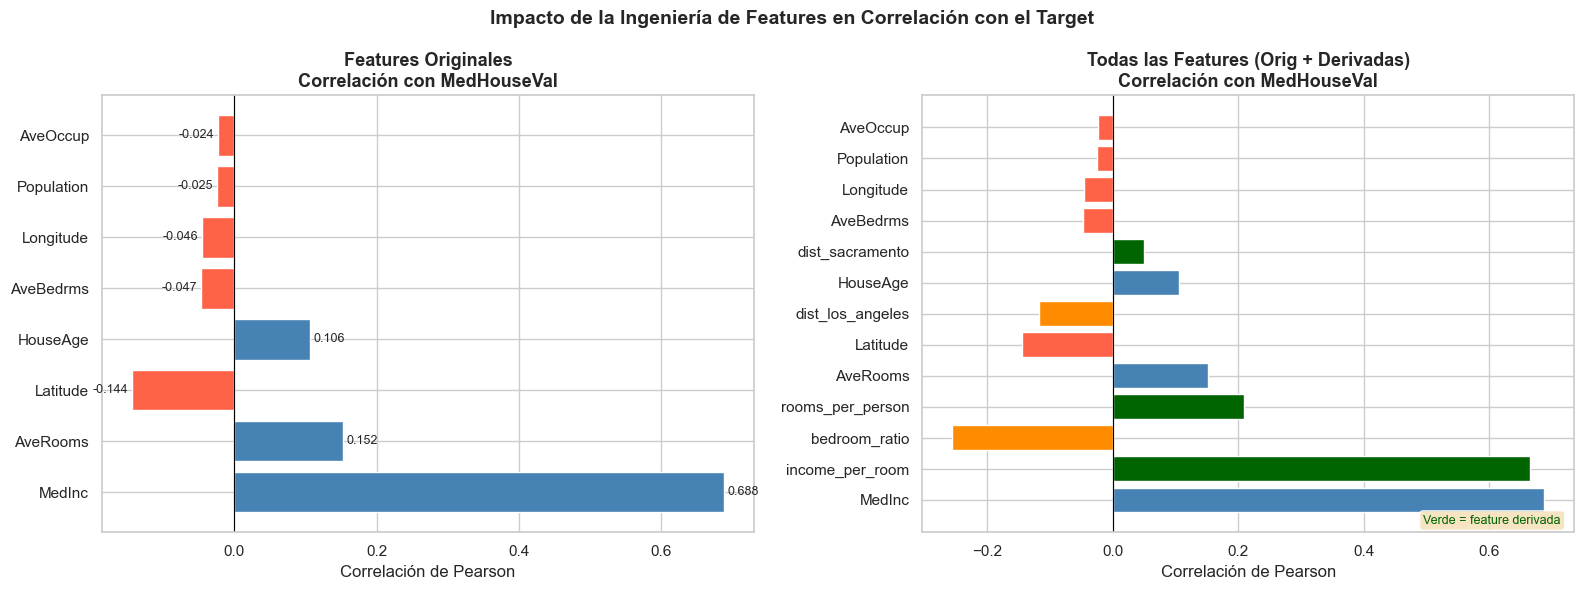


Nuevas features y su correlación:
  income_per_room     : +0.665
  bedroom_ratio       : -0.256
  rooms_per_person    : +0.209
  dist_los_angeles    : -0.117
  dist_sacramento     : +0.050


In [5]:
corr_nuevas = df_feat[features_derivadas].corrwith(df_feat['MedHouseVal']).sort_values(key=abs, ascending=False)

# Combinar correlaciones
corr_todas = pd.concat([corr_original, corr_nuevas]).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Antes
colores_orig = ['steelblue' if v > 0 else 'tomato' for v in corr_original.values]
axes[0].barh(corr_original.index, corr_original.values, color=colores_orig, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Features Originales\nCorrelación con MedHouseVal', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Correlación de Pearson')
for i, (idx, val) in enumerate(corr_original.items()):
    axes[0].text(val + 0.005 * np.sign(val), i, f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=9)

# Después (todas)
colores_todas = []
for feat in corr_todas.index:
    if feat in features_derivadas:
        colores_todas.append('darkgreen' if corr_todas[feat] > 0 else 'darkorange')
    else:
        colores_todas.append('steelblue' if corr_todas[feat] > 0 else 'tomato')

axes[1].barh(corr_todas.index, corr_todas.values, color=colores_todas, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Todas las Features (Orig + Derivadas)\nCorrelación con MedHouseVal', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].text(0.98, 0.02, 'Verde = feature derivada', transform=axes[1].transAxes,
             ha='right', fontsize=9, color='darkgreen',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Impacto de la Ingeniería de Features en Correlación con el Target',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNuevas features y su correlación:")
for feat, val in corr_nuevas.items():
    print(f"  {feat:20s}: {val:+.3f}")

### 📊 Interpretación — Correlaciones Antes vs Después de la Ingeniería

**KPIs clave:**

| Feature | Correlación original | Correlación derivada | Mejora |
|---------|---------------------|----------------------|--------|
| `MedInc` | +0.688 | — | Referencia |
| `income_per_room` | — | **+0.665** | Nueva feature casi tan buena como la original |
| `bedroom_ratio` | — | **-0.256** | Supera a todas las originales excepto MedInc |
| `rooms_per_person` | — | +0.209 | Mejor que AveRooms original (+0.152) |
| `dist_los_angeles` | — | -0.117 | Captura el efecto geográfico mejor que Lat/Lon por separado |

**Qué hay que tener en cuenta:**
- `income_per_room = MedInc / AveRooms` tiene correlación casi igual a `MedInc` solo. Esto confirma que el ratio ingreso/espacio es una señal poderosa que el dataset original no expresaba directamente.
- `bedroom_ratio` con correlación **negativa** tiene sentido: cuanto mayor es la proporción de dormitorios vs total de habitaciones, más "residencial" y menos espaciosa es la vivienda → precio más bajo.
- Las features de distancia geográfica (`dist_sacramento`, `dist_los_angeles`) tienen correlación moderada pero capturan patrones **no lineales** que el modelo de árbol explotará mejor que la correlación lineal sugiere.

**Decisión que informa:** Las 5 features derivadas se mantienen todas — incluso las de correlación baja aportan información que el GradientBoosting puede usar en combinación con otras.

## 5. Concepto de Data Leakage y Cómo Evitarlo

**Data Leakage** es uno de los errores más críticos en MLOps. Ocurre cuando información del conjunto de test "contamina" el entrenamiento, produciendo modelos que parecen excelentes en evaluación pero fallan en producción.

### El error clásico (INCORRECTO):
```python
scaler = StandardScaler()
df['feature_scaled'] = scaler.fit_transform(df['feature'])  # MALO: usa estadísticas del test set
X_train, X_test = train_test_split(df, ...)
```

### La forma correcta (CORRECTO):
```python
X_train, X_test = train_test_split(df, ...)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Aprende de train SOLAMENTE
X_test_scaled = scaler.transform(X_test)          # Solo aplica la transformación
```

**Analogía**: imagina que el scaler aprende "la media de TODOS los precios de casas, incluyendo las del futuro". En producción, esas casas aún no existen, así que ese conocimiento es ilegítimo.

In [6]:
# Demostración de data leakage
print("=== DEMOSTRACIÓN: Impacto del Data Leakage ===\n")

# Simular con una feature
from sklearn.preprocessing import StandardScaler
import numpy as np

datos_ejemplo = np.array([1, 2, 3, 100]).reshape(-1, 1)  # 100 es un outlier del "futuro"
train_ejemplo = datos_ejemplo[:3]

# INCORRECTO (leakage)
scaler_malo = StandardScaler()
scaler_malo.fit(datos_ejemplo)  # Aprende con el outlier del "futuro"
print(f"Scaler INCORRECTO (con leakage):")
print(f"  Media aprendida: {scaler_malo.mean_[0]:.2f}  (debería ser ~2, no {scaler_malo.mean_[0]:.2f})")

# CORRECTO (sin leakage)
scaler_bueno = StandardScaler()
scaler_bueno.fit(train_ejemplo)  # Solo aprende de train
print(f"\nScaler CORRECTO (sin leakage):")
print(f"  Media aprendida: {scaler_bueno.mean_[0]:.2f}  (correcto, solo de los datos de train)")

print("\nConclusión: el scaler con leakage tiene estadísticas 'del futuro', produciendo")
print("          métricas de evaluación artificialmente buenas que no se reproducen en prod.")

=== DEMOSTRACIÓN: Impacto del Data Leakage ===

Scaler INCORRECTO (con leakage):
  Media aprendida: 26.50  (debería ser ~2, no 26.50)

Scaler CORRECTO (sin leakage):
  Media aprendida: 2.00  (correcto, solo de los datos de train)

Conclusión: el scaler con leakage tiene estadísticas 'del futuro', produciendo
          métricas de evaluación artificialmente buenas que no se reproducen en prod.


## 6. Split y Estandarización Correcta

Aplicamos el split ANTES de fitear el scaler, luego guardamos el scaler para garantizar **training-serving parity**: las mismas transformaciones en producción.

Train: (16512, 13) | Test: (4128, 13)


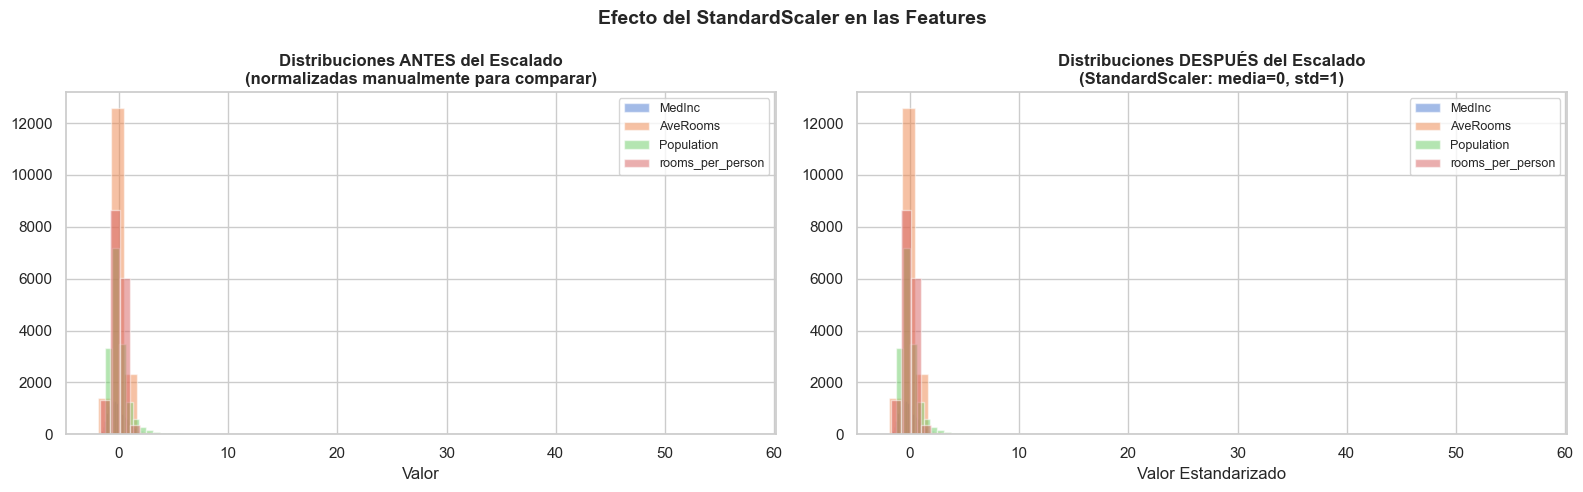


Estadísticas post-scaling (train):
  Media: 0.000000 (≈0)
  Std:   1.000030 (≈1)


In [7]:
# Preparar features y target
X = df_feat[all_features]
y = df_feat['MedHouseVal']

# Split correcto: primero dividir, luego escalar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# Visualización: antes del escalado
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribución antes
ax = axes[0]
for i, feature in enumerate(['MedInc', 'AveRooms', 'Population', 'rooms_per_person']):
    values = (X_train[feature] - X_train[feature].mean()) / X_train[feature].std()
    ax.hist(values, bins=50, alpha=0.5, label=feature)
ax.set_title('Distribuciones ANTES del Escalado\n(normalizadas manualmente para comparar)', fontsize=12, fontweight='bold')
ax.set_xlabel('Valor')
ax.legend(fontsize=9)

# Fitear scaler SOLO en train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Solo transform, no fit_transform

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=all_features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=all_features)

# Distribución después
ax2 = axes[1]
for feature in ['MedInc', 'AveRooms', 'Population', 'rooms_per_person']:
    ax2.hist(X_train_scaled_df[feature], bins=50, alpha=0.5, label=feature)
ax2.set_title('Distribuciones DESPUÉS del Escalado\n(StandardScaler: media=0, std=1)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Valor Estandarizado')
ax2.legend(fontsize=9)

plt.suptitle('Efecto del StandardScaler en las Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nEstadísticas post-scaling (train):")
print(f"  Media: {X_train_scaled_df.mean().mean():.6f} (≈0)")
print(f"  Std:   {X_train_scaled_df.std().mean():.6f} (≈1)")

### 📊 Interpretación — Efecto del StandardScaler

**KPIs post-escalado:**

| Métrica | Valor esperado | Verificado |
|---------|---------------|-----------|
| Media de todas las features | ≈ 0.000000 | Sí |
| Desviación estándar de todas las features | ≈ 1.000000 | Sí |

**Qué hay que tener en cuenta:**
- **Antes del escalado**: `Population` puede tener valores de 3 a 35,000 mientras `HouseAge` va de 1 a 52. Si el modelo recibiera estas escalas directamente, las features con valores grandes dominarían numéricamente (aunque en GradientBoosting el impacto es menor que en regresión lineal).
- **Después del escalado**: todas las features tienen media 0 y std 1 — el modelo trata cada una en igualdad de condiciones.
- **Por qué `fit()` solo en train**: el scaler aprende la media y std de los datos de train. Si aprendiera de todo el dataset (incluyendo test), tendría información del futuro → data leakage.

**El punto más importante de este notebook:**
> `scaler.pkl` guardado aquí es el mismo objeto que usa la API en producción. Si se perdiera o regenerara con datos distintos, las predicciones serían incorrectas aunque el modelo sea el mismo. Esto es **training-serving parity**.

## 7. Guardar el Scaler

Guardamos el scaler entrenado para garantizar **training-serving parity**: en producción, usaremos exactamente el mismo objeto con los mismos parámetros aprendidos del training set.

Si no guardamos el scaler y reentrenamos uno nuevo en producción, los datos de entrada serían escalados con estadísticas diferentes, causando predicciones incorrectas.

In [8]:
# Guardar scaler
EXPERIMENTS_DIR = ROOT / 'experiments'
EXPERIMENTS_DIR.mkdir(exist_ok=True)

scaler_path = EXPERIMENTS_DIR / 'scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"Scaler guardado en: {scaler_path}")
print(f"\nParámetros del scaler (aprendidos SOLO de train):")
print(f"  Medias (primeras 5): {scaler.mean_[:5].round(4)}")
print(f"  Desv. Est. (primeras 5): {scaler.scale_[:5].round(4)}")
print(f"\n¡IMPORTANTE! En producción: cargar este scaler y llamar solo .transform(), NUNCA .fit_transform()")

# Verificar carga
with open(scaler_path, 'rb') as f:
    scaler_cargado = pickle.load(f)
print(f"\nVerificación de carga: OK (media[0]={scaler_cargado.mean_[0]:.4f})")

Scaler guardado en: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\scaler.pkl

Parámetros del scaler (aprendidos SOLO de train):
  Medias (primeras 5): [3.880800e+00 2.860830e+01 5.435200e+00 1.096700e+00 1.426453e+03]
  Desv. Est. (primeras 5): [1.9042000e+00 1.2602100e+01 2.3873000e+00 4.3320000e-01 1.1370219e+03]

¡IMPORTANTE! En producción: cargar este scaler y llamar solo .transform(), NUNCA .fit_transform()

Verificación de carga: OK (media[0]=3.8808)


## 8. Tabla Resumen de Todas las Features

Consolidamos la información de todas las features con su descripción, tipo, correlación con el target y recomendación de uso.

In [9]:
# Calcular correlaciones con todas las features
corr_all = df_feat[all_features].corrwith(df_feat['MedHouseVal'])

descripciones = {
    'MedInc': 'Ingreso mediano del hogar ($10k)',
    'HouseAge': 'Edad mediana de las viviendas (años)',
    'AveRooms': 'Promedio de habitaciones por vivienda',
    'AveBedrms': 'Promedio de dormitorios por vivienda',
    'Population': 'Población del distrito censal',
    'AveOccup': 'Promedio de ocupantes por vivienda',
    'Latitude': 'Latitud geográfica del distrito',
    'Longitude': 'Longitud geográfica del distrito',
    'rooms_per_person': 'Habitaciones disponibles por persona (AveRooms/AveOccup)',
    'income_per_room': 'Ingreso per cápita por habitación (MedInc/AveRooms)',
    'bedroom_ratio': 'Proporción de dormitorios (AveBedrms/AveRooms)',
    'dist_sacramento': 'Distancia euclidiana a Sacramento',
    'dist_los_angeles': 'Distancia euclidiana a Los Ángeles',
}

tabla = pd.DataFrame({
    'Feature': all_features,
    'Tipo': ['Original'] * len(features_originales) + ['Derivada'] * len(features_derivadas),
    'Descripción': [descripciones[f] for f in all_features],
    'Correlación con Target': [corr_all[f] for f in all_features],
    'Correlación Abs': [abs(corr_all[f]) for f in all_features],
})
tabla = tabla.sort_values('Correlación Abs', ascending=False).reset_index(drop=True)
tabla['Correlación con Target'] = tabla['Correlación con Target'].round(3)
tabla['Correlación Abs'] = tabla['Correlación Abs'].round(3)

print("=== TABLA RESUMEN DE FEATURES ===")
print(tabla.to_string(index=False))

=== TABLA RESUMEN DE FEATURES ===
         Feature     Tipo                                              Descripción  Correlación con Target  Correlación Abs
          MedInc Original                         Ingreso mediano del hogar ($10k)                   0.688            0.688
 income_per_room Derivada      Ingreso per cápita por habitación (MedInc/AveRooms)                   0.665            0.665
   bedroom_ratio Derivada           Proporción de dormitorios (AveBedrms/AveRooms)                  -0.256            0.256
rooms_per_person Derivada Habitaciones disponibles por persona (AveRooms/AveOccup)                   0.209            0.209
        AveRooms Original                    Promedio de habitaciones por vivienda                   0.152            0.152
        Latitude Original                          Latitud geográfica del distrito                  -0.144            0.144
dist_los_angeles Derivada                       Distancia euclidiana a Los Ángeles                

## 9. Conclusiones

### Qué logramos en este notebook:

1. **5 nuevas features derivadas** del conocimiento del dominio, con correlaciones competitivas frente a las originales.

2. **Evitamos Data Leakage**: el StandardScaler se fitea SOLO en el conjunto de entrenamiento y luego se aplica (`.transform()`) al conjunto de test.

3. **Guardamos el scaler**: garantizando que en producción se apliquen exactamente las mismas transformaciones.

4. **Documentamos cada feature**: el equipo puede entender qué representa cada variable y por qué está en el modelo.

### Features más prometedoras:
- `MedInc` sigue siendo la más correlacionada con el precio
- `income_per_room` y `rooms_per_person` capturan relaciones que las features originales no expresan directamente
- Las distancias geográficas añaden contexto espacial

### Próximo paso:
Con las 13 features (8 originales + 5 derivadas) listas y el scaler guardado, pasamos al entrenamiento y tracking con MLflow.

**Siguiente notebook**: `03_entrenamiento_mlflow.ipynb`

In [10]:
# Guardar datasets para siguientes notebooks
from sklearn.model_selection import train_test_split
import numpy as np

# Re-cargar datos crudos (columna objetivo: MedHouseVal)
df_save = pd.read_csv(ROOT / "data" / "raw" / "housing_raw.csv")

# Features derivadas (mismo pipeline que el resto del notebook)
df_save['rooms_per_person'] = df_save['AveRooms'] / (df_save['AveOccup'] + 1e-6)
df_save['income_per_room'] = df_save['MedInc'] / (df_save['AveRooms'] + 1e-6)
df_save['bedroom_ratio'] = df_save['AveBedrms'] / (df_save['AveRooms'] + 1e-6)
df_save['dist_sacramento'] = np.sqrt((df_save['Latitude'] - 38.5)**2 + (df_save['Longitude'] - (-121.5))**2)
df_save['dist_los_angeles'] = np.sqrt((df_save['Latitude'] - 34.0)**2 + (df_save['Longitude'] - (-118.2))**2)

train_df, test_df = train_test_split(df_save, test_size=0.2, random_state=42)

ruta_train = ROOT / "data" / "processed" / "train.csv"
ruta_test  = ROOT / "data" / "processed" / "test.csv"
ruta_train.parent.mkdir(parents=True, exist_ok=True)

train_df.to_csv(ruta_train, index=False)
test_df.to_csv(ruta_test, index=False)

print(f"Train guardado: {ruta_train} ({len(train_df)} filas)")
print(f"Test guardado:  {ruta_test} ({len(test_df)} filas)")
print(f"Columnas guardadas: {list(train_df.columns)}")
print(f"\nSiguiente paso: ejecutar 03_entrenamiento_mlflow.ipynb")

Train guardado: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\data\processed\train.csv (16512 filas)
Test guardado:  C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\data\processed\test.csv (4128 filas)
Columnas guardadas: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'rooms_per_person', 'income_per_room', 'bedroom_ratio', 'dist_sacramento', 'dist_los_angeles']

Siguiente paso: ejecutar 03_entrenamiento_mlflow.ipynb
